# Logistic Regression for Malware Detection

This notebook implements a Logistic Regression model for binary classification of malware vs goodware.

## Steps:
1. Load and explore the dataset
2. Preprocess the data
3. Split into train/test sets (80/20)
4. Train Logistic Regression model
5. Evaluate using 10-fold cross-validation
6. Test on hold-out test set
7. Save the model

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load and Explore Dataset

In [3]:
# Load the dataset
df = pd.read_csv('../dataset/brazilian-malware-dataset/brazilian-malware.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (50181, 28)

First few rows:


,BaseOfCode,BaseOfData,Characteristics,DllCharacteristics,Entropy,FileAlignment,FirstSeenDate,Identify,ImageBase,ImportedDlls,...,PointerToSymbolTable,SHA1,Size,SizeOfCode,SizeOfHeaders,SizeOfImage,SizeOfInitializedData,SizeOfOptionalHeader,SizeOfUninitializedData,TimeDateStamp
0,4096,69632,783,0,5.981249,512,1970-01-01,powerbasic/win 8.00,4194304,comdlg32.dll gdi32.dll kernel32.dll ole32.dll ...,...,0,b0068836a40e6a43c6b546fcb709237e5aa223d1,76288,64855,1024,86016,2560,224,1500,12345
1,4096,1851392,783,0,6.081747,512,1970-01-01,NaN,4194304,comctl32.dll comdlg32.dll gdi32.dll kernel32.d...,...,0,5741708cd785f13b44267883e3f2fd2fa51fc23f,2558464,1843888,1024,2600960,500348,224,21476,0
2,4096,40960,783,0,5.586422,512,1970-01-01,NaN,4194304,comdlg32.dll kernel32.dll msvcrt.dll msvcrt.dl...,...,0,507fe5d8244f33d29d427468efca4ce406f23666,178688,33792,1024,33759232,177664,224,33557504,0
3,1359872,2138112,783,0,7.969464,512,1970-01-01,"upx 2.93 - 3.00 [lzma] -> markus oberhumer, la...",4194304,kernel32.dll advapi32.dll comdlg32.dll gdi32.d...,...,0,e51a7811464be1acadf6e72ba3a66aba0da438cd,806816,778240,4096,2166784,28672,224,1355776,0
4,4096,40960,783,32768,7.999900,512,1970-01-01,NaN,4194304,advapi32.dll comctl32.dll gdi32.dll kernel32.d...,...,0,0e046d9903c313ffeeb0d6392335437fe881b1f5,50689096,35840,1024,303104,38912,224,110080,0


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Missing values per column:
BaseOfCode                     0
BaseOfData                     0
Characteristics                0
DllCharacteristics             0
Entropy                        0
FileAlignment                  0
FirstSeenDate                  0
Identify                   14223
ImageBase                      0
ImportedDlls                   0
ImportedSymbols                0
Label                          0
Machine                        0
Magic                          0
NumberOfRvaAndSizes            0
NumberOfSections               0
NumberOfSymbols                0
PE_TYPE                        0
PointerToSymbolTable           0
SHA1                           0
Size                           0
SizeOfCode                     0
SizeOfHeaders                  0
SizeOfImage                    0
SizeOfInitializedData          0
SizeOfOptionalHeader           0
SizeOfUninitializedData        0
TimeDateStamp                  0
dtype: int64

Data types:
BaseOfCode             

Class distribution:
Label
1    29065
0    21116
Name: count, dtype: int64

Class balance: Label
1    0.579203
0    0.420797
Name: proportion, dtype: float64


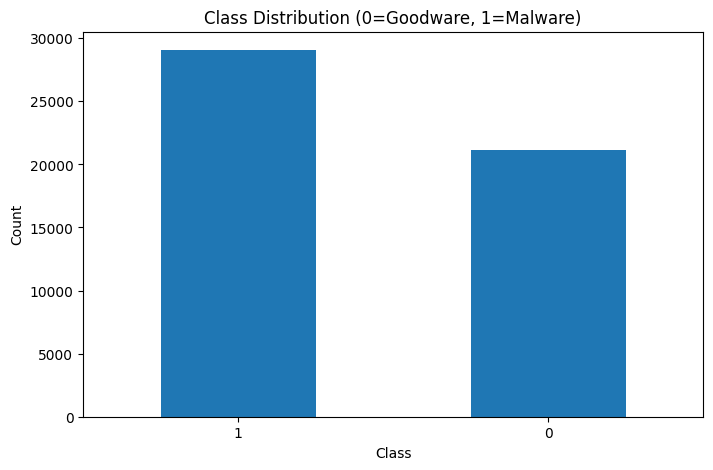

In [5]:
# Check class distribution
print("Class distribution:")
print(df['Label'].value_counts())
print(f"\nClass balance: {df['Label'].value_counts(normalize=True)}")

# Visualize class distribution
plt.figure(figsize=(8, 5))
df['Label'].value_counts().plot(kind='bar')
plt.title('Class Distribution (0=Goodware, 1=Malware)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 2. Data Preprocessing

In [6]:
# Separate features and target
# Drop non-numeric columns (SHA1, FirstSeenDate, etc.) if present
X = df.drop('Label', axis=1)

# Keep only numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
X = X[numeric_cols]

y = df['Label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (50181, 22)
Target shape: (50181,)

Feature columns: ['BaseOfCode', 'BaseOfData', 'Characteristics', 'DllCharacteristics', 'Entropy', 'FileAlignment', 'ImageBase', 'Machine', 'Magic', 'NumberOfRvaAndSizes', 'NumberOfSections', 'NumberOfSymbols', 'PE_TYPE', 'PointerToSymbolTable', 'Size', 'SizeOfCode', 'SizeOfHeaders', 'SizeOfImage', 'SizeOfInitializedData', 'SizeOfOptionalHeader', 'SizeOfUninitializedData', 'TimeDateStamp']


In [ ]:
# Handle missing values (if any)
if X.isnull().sum().sum() > 0:
    print("Filling missing values with 0...")
    X = X.fillna(0)
else:
    print("No missing values found.")

## 3. Train/Test Split (80/20)

**Important**: We split BEFORE scaling to prevent data leakage.

In [ ]:
# Split into train and test sets (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

## 4. Feature Scaling

**Critical**: Fit scaler ONLY on training data, then transform both train and test.

In [ ]:
# Initialize and fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Training data mean: {X_train_scaled.mean():.6f}")
print(f"Training data std: {X_train_scaled.std():.6f}")

## 5. Train Logistic Regression Model

In [ ]:
# Initialize Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all CPU cores
)

# Train the model
print("Training Logistic Regression model...")
log_reg.fit(X_train_scaled, y_train)
print("Model training complete!")

## 6. Cross-Validation Evaluation (10-Fold)

Using stratified 10-fold cross-validation on the training set.

In [ ]:
# Perform 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print("Performing 10-fold cross-validation...")
cv_results = cross_validate(
    log_reg, 
    X_train_scaled, 
    y_train,
    cv=cv,
    scoring=['roc_auc', 'accuracy'],
    n_jobs=-1,
    return_train_score=False
)

# Display results
print("\n=== Cross-Validation Results ===")
print(f"AUC: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

## 7. Final Evaluation on Hold-Out Test Set

In [ ]:
# Make predictions on test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_pred_proba)

print("\n=== Test Set Results ===")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"AUC: {test_auc:.4f}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Goodware', 'Malware'],
            yticklabels=['Goodware', 'Malware'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Goodware', 'Malware']))

## 8. Feature Importance Analysis

In [ ]:
# Get feature coefficients
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize top features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['coefficient'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients - Logistic Regression')
plt.tight_layout()
plt.show()

## 9. Save Model and Scaler

In [ ]:
# Create models directory if it doesn't exist
import os
os.makedirs('../models', exist_ok=True)

# Save the model
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(log_reg, f)
print("Model saved to ../models/logistic_regression.pkl")

# Save the scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to ../models/scaler.pkl")

## Summary

This notebook demonstrated:
1. ✅ Loading and exploring the malware dataset
2. ✅ Preprocessing with proper train/test split
3. ✅ Feature scaling (fit on train, transform on test)
4. ✅ Training a Logistic Regression model
5. ✅ 10-fold stratified cross-validation
6. ✅ Evaluation on hold-out test set
7. ✅ Feature importance analysis
8. ✅ Model serialization for production use

**Key Results:**
- Cross-Validation AUC: [See results above]
- Test Set AUC: [See results above]
- Test Set Accuracy: [See results above]